In [918]:
#Data Loading

import pandas as pd

df = pd.read_csv("data.csv")

df.head(5)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,center_code,police_station,data_sent_to_scita,junction_name,action_taken_timestamp,data_sent_to_scita_timestamp,updated_vehicle_number,updated_vehicle_type,validation_status,validation_timestamp
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0000,MAXI-CAB,approved,2023-11-30 03:08:24.818+00
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46+00,...,82.0,Bellandur,False,No Junction,NaN,NaN,NaN,NaN,NaN,NaN
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46+00,...,9.0,Madiwala,True,No Junction,NaN,NaN,FKN00GL0002,MAXI-CAB,approved,2023-11-30 03:08:56.998+00
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46+00,...,26.0,Byatarayanapura,True,No Junction,NaN,NaN,FKN00GL0003,SCOOTER,approved,2023-11-18 23:35:12.428+00
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46+00,...,3.0,Upparpet,True,BTP044 - Sagar Theatre Junction,NaN,NaN,FKN00GL0004,TANKER,approved,2023-11-30 03:11:32.796+00


In [919]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 298450 entries, 0 to 298449
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            298450 non-null  object 
 1   latitude                      298450 non-null  float64
 2   longitude                     298450 non-null  float64
 3   location                      295409 non-null  object 
 4   vehicle_number                298450 non-null  object 
 5   vehicle_type                  298450 non-null  object 
 6   description                   0 non-null       float64
 7   violation_type                298450 non-null  object 
 8   offence_code                  298450 non-null  object 
 9   created_datetime              298450 non-null  object 
 10  closed_datetime               0 non-null       float64
 11  modified_datetime             298450 non-null  object 
 12  device_id                     298450 non-nul

In [920]:
#Data Cleaning
print(df.isnull().sum())

id                                   0
latitude                             0
longitude                            0
location                          3041
vehicle_number                       0
vehicle_type                         0
description                     298450
violation_type                       0
offence_code                         0
created_datetime                     0
closed_datetime                 298450
modified_datetime                    0
device_id                            0
created_by_id                        5
center_code                      11260
police_station                       5
data_sent_to_scita                   0
junction_name                        5
action_taken_timestamp          298450
data_sent_to_scita_timestamp    256289
updated_vehicle_number          125254
updated_vehicle_type            125254
validation_status               125254
validation_timestamp            125254
dtype: int64


In [921]:
# Unwanted Columns List
unwanted_cols = ['description','closed_datetime','action_taken_timestamp']
df_cleaned = df.drop(columns=unwanted_cols, errors='ignore') 


In [922]:
# DATETIME PROCESSING
df['created_datetime'] = pd.to_datetime(
    df['created_datetime'],
    format='mixed'
)

In [923]:

df["created_datetime_ist"] = (
    df["created_datetime"]
    .dt.tz_convert("Asia/Kolkata")
)

df["hour_ist"] = df["created_datetime_ist"].dt.hour

print(df["hour_ist"].value_counts().sort_index())

hour_ist
0      5815
1     11098
2     16261
3     21565
4     23513
5     22193
6     19838
7     19445
8     25790
9     26996
10    32580
11    32176
12    19689
13    11546
14     5634
15     1224
16      583
17      377
18      150
19       27
20       42
21      148
22      725
23     1035
Name: count, dtype: int64


In [924]:
df["hour_ist"] = (
    df["created_datetime_ist"]
    .dt.hour
)

df["day"] = (
    df["created_datetime_ist"]
    .dt.day
)

df["month"] = (
    df["created_datetime_ist"]
    .dt.month
)

df["weekday"] = (
    df["created_datetime_ist"]
    .dt.weekday
)

df["weekend"] = (
    df["weekday"] >= 5
).astype(int)

In [925]:
#Exploratory Data Analysis (EDA)

#1 Vehicle Type Analysis
print(df["vehicle_type"].value_counts().head(20))


vehicle_type
SCOOTER                94856
CAR                    88870
MOTOR CYCLE            40811
PASSENGER AUTO         37813
MAXI-CAB               11372
LGV                     8255
GOODS AUTO              2934
MOPED                   2199
PRIVATE BUS             1633
VAN                     1466
TEMPO                   1368
BUS (BMTC/KSRTC)        1281
HGV                     1144
LORRY/GOODS VEHICLE     1122
JEEP                     913
OTHERS                   895
TOURIST BUS              379
SCHOOL VEHICLE           378
TANKER                   260
FACTORY BUS              238
Name: count, dtype: int64


In [926]:
#2 Police Station Analysis
print(df["police_station"].value_counts().head(20))

police_station
Upparpet                  34468
Shivajinagar              28044
Malleshwaram              22200
HAL Old Airport           20819
City Market               17646
Vijayanagara              14652
Rajajinagar               10998
Kodigehalli               10916
Magadi Road                8558
Jeevanbheemanagar          6736
K.R. Pura                  6546
Halasuru Gate              6294
Mahadevapura               6187
Chikkajala                 5834
HSR Layout                 5018
Bellandur                  4964
High ground                4951
Byatarayanapura            4555
Electronic City            4333
Pulikeshinagar(F.Town)     4136
Name: count, dtype: int64


In [927]:
#3 Junction Analysis
print(df["junction_name"].value_counts().head(20))

junction_name
No Junction                                   147880
BTP051 - Safina Plaza Junction                 15449
BTP082 - KR Market Junction                    11538
BTP040 - Elite Junction                        10718
BTP044 - Sagar Theatre Junction                10549
BTP211 - Central Street Junction                5388
BTP058 - Subbanna Junction                      5189
BTP027 - Modi Bridge Junction                   4584
BTP020 - Hosahalli Metro Station                4101
BTP057 - Anand Rao Junction                     3935
BTP080 - NR Road, SP Road Junction              3681
BTP045 - Danvanthri Road Junction               3181
BTP001 - 10th Cross, Dr. Rajkumar Road          2812
BTP083 - AS Char Street, Mysore Road            2778
BTP032 - Windsor Circle                         2749
BTP016 - 5th Main Road, RPC Layout              2474
BTP070 - Cholurpalya Junction, Magadi Road      2272
BTP042 - Minsk Square Junction (CTO)            2044
BTP038 - Mysore Bank Junction   

In [928]:
#4 Violation Analysis
df["violation_type"].value_counts().head(20)

violation_type
["WRONG PARKING"]                                           138764
["NO PARKING"]                                              119576
["PARKING IN A MAIN ROAD","WRONG PARKING"]                    9472
["PARKING IN A MAIN ROAD","NO PARKING"]                       4818
["WRONG PARKING","DEFECTIVE NUMBER PLATE"]                    3317
["NO PARKING","PARKING IN A MAIN ROAD"]                       2449
["NO PARKING","DEFECTIVE NUMBER PLATE"]                       2380
["WRONG PARKING","PARKING IN A MAIN ROAD"]                    1955
["PARKING ON FOOTPATH","WRONG PARKING"]                       1190
["NO PARKING","WRONG PARKING"]                                 891
["PARKING IN A MAIN ROAD","WRONG PARKING","NO PARKING"]        865
["WRONG PARKING","NO PARKING"]                                 827
["PARKING ON FOOTPATH","NO PARKING"]                           682
["NO PARKING","WRONG PARKING","PARKING IN A MAIN ROAD"]        675
["WRONG PARKING","PARKING ON FOOTPATH"]        

<Axes: xlabel='hour_ist'>

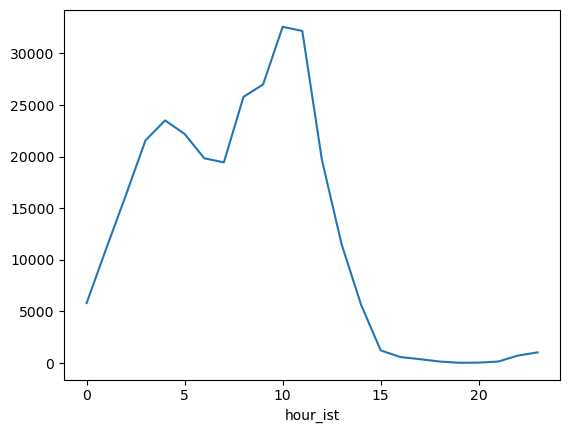

In [929]:
#5 Time Analysis
df["hour_ist"].value_counts().sort_index().plot()

In [930]:
#6 Hotspot Locations
location_stats = (
    df.groupby("location")
    .size()
    .reset_index(name="violations")
)

location_stats.sort_values(
    "violations",
    ascending=False
).head(20)

,location,violations
10458,"Unnamed Road, Begur Chikkanahalli, Bengaluru, ...",4090
6971,"Kamaraj Road, Sri Nagamma Devi Circle, Sivanch...",3999
8359,"New Horizon College Road, New Horizon College ...",3785
7490,"MBT Road, Devasandra Junction, KR Puram, Benga...",3027
5393,"Dispensary Road, Tasker Town, Shivaji Nagar, B...",2670
4630,"Bellary Road, Vinayaka Nagar, Hebbal, Bengalur...",2639
2972,"5th Main Road, Kempe Gowda Circle, Gandhi Naga...",2604
7734,"Main Guard Cross Road, Tasker Town, Shivaji Na...",2549
8357,"New Horizon College Road, Embassy Tech Village...",2416
2189,"3rd Cross Road, Kempegowda Extension, Chickpet...",2315


In [931]:
# FEATURE ENGINEERING
# 1. Create Daily Location Dataset

daily_location = (
    df.groupby([
        df["created_datetime_ist"].dt.date,
        "location"
    ])
    .size()
    .reset_index(name="violations")
)

daily_location.rename(
    columns={"created_datetime_ist": "date"},
    inplace=True
)

daily_location["date"] = pd.to_datetime(
    daily_location["date"]
)

print(daily_location.head())
print(daily_location.shape)

        date                                           location  violations
0 2023-11-10  100 Feet Road, KFC Circle, Indiranagar, Bengal...           1
1 2023-11-10  11th Main Road, Block 4T East, Jayanagar, Beng...           3
2 2023-11-10  12th Cross Road, Ideal Homes Township Circle, ...           3
3 2023-11-10  12th Cross Road, Mahalakshmi Layout, Mahalaksh...           1
4 2023-11-10  12th Cross Road, Sri Pattanagere Jayanna Circl...           2
(72972, 3)


In [932]:
# Date features.
daily_location["day"] = (
    daily_location["date"].dt.day
)

daily_location["month"] = (
    daily_location["date"].dt.month
)

daily_location["weekday"] = (
    daily_location["date"].dt.weekday
)

daily_location["weekend"] = (
    daily_location["weekday"] >= 5
).astype(int)

In [933]:
# Sort before lag features.
daily_location = (
    daily_location
    .sort_values(
        ["location","date"]
    )
)

In [934]:
# Lag Features.
daily_location["prev_day_violations"] = (
    daily_location
    .groupby("location")
    ["violations"]
    .shift(1)
)

daily_location["lag2"] = (
    daily_location
    .groupby("location")
    ["violations"]
    .shift(2)
)

daily_location["lag7"] = (
    daily_location
    .groupby("location")
    ["violations"]
    .shift(7)
)

In [935]:
# Rolling Features.
daily_location["rolling_3day"] = (
    daily_location
    .groupby("location")
    ["violations"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(3,min_periods=1)
        .mean()
    )
)

daily_location["rolling_7day"] = (
    daily_location
    .groupby("location")
    ["violations"]
    .transform(
        lambda x:
        x.shift(1)
        .rolling(7,min_periods=1)
        .mean()
    )
)

In [936]:
# Location statistics.
location_freq = (
    daily_location["location"]
    .value_counts()
)

daily_location["location_freq"] = (
    daily_location["location"]
    .map(location_freq)
)

In [937]:
#Mean violations at location
location_avg = (
    daily_location
    .groupby("location")
    ["violations"]
    .mean()
)

daily_location["location_avg"] = (
    daily_location["location"]
    .map(location_avg)
)

In [938]:
# Std deviations
location_std = (
    daily_location
    .groupby("location")
    ["violations"]
    .std()
)

daily_location["location_std"] = (
    daily_location["location"]
    .map(location_std)
)

In [939]:
# Monthly average
month_avg = (
    daily_location
    .groupby("month")
    ["violations"]
    .mean()
)

daily_location["month_avg"] = (
    daily_location["month"]
    .map(month_avg)
)

In [940]:
# Remove nulls.
daily_location = (
    daily_location
    .dropna()
)

In [941]:
# RISK LABEL CREATION

#LOW → Below 50th percentile
# MEDIUM → 50th–85th percentile
# HIGH → Above 85th percentile

q50 = daily_location["violations"].quantile(0.50)
q85 = daily_location["violations"].quantile(0.85)

def create_risk(v):

    if v <= q50:
        return "LOW"

    elif v <= q85:
        return "MEDIUM"

    else:
        return "HIGH"

In [942]:
daily_location["risk_level"] = (
    daily_location["violations"]
    .apply(create_risk)
)

In [943]:
# MODEL TRAINING
# Features.
features = [
    "location_freq",
    "location_avg",
    "location_std",
    "month_avg",
    "day",
    "month",
    "weekday",
    "weekend",
    "prev_day_violations",
    "lag2",
    "lag7",
    "rolling_3day",
    "rolling_7day"
]

In [944]:
# Target
X = daily_location[features]

y = daily_location["risk_level"]

In [945]:
# Time split
daily_location = (
    daily_location
    .sort_values("date")
)

split_idx = int(
    len(daily_location)*0.8
)

train = daily_location.iloc[:split_idx]

test = daily_location.iloc[split_idx:]

In [946]:
X_train = train[features]
X_test = test[features]

y_train = train["risk_level"]
y_test = test["risk_level"]

In [947]:
# Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=300, random_state=42)

In [948]:
# Evaluation
predictions = model.predict(
    X_test
)

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    accuracy_score(
        y_test,
        predictions
    )
)

print(
    classification_report(
        y_test,
        predictions
    )
)

rf_acc = accuracy_score(
    y_test,
    predictions
)

0.6152593335003759
              precision    recall  f1-score   support

        HIGH       0.54      0.36      0.43       982
         LOW       0.69      0.82      0.75      4492
      MEDIUM       0.44      0.35      0.39      2508

    accuracy                           0.62      7982
   macro avg       0.56      0.51      0.52      7982
weighted avg       0.59      0.62      0.60      7982



In [949]:
# Feature Importance
importance = pd.DataFrame(
    {
        "Feature": features,
        "Importance":
        model.feature_importances_
    }
)

importance.sort_values(
    "Importance",
    ascending=False
)

,Feature,Importance
1,location_avg,0.154684
2,location_std,0.127800
12,rolling_7day,0.113691
0,location_freq,0.096358
11,rolling_3day,0.092415
4,day,0.092165
10,lag7,0.067318
8,prev_day_violations,0.065216
9,lag2,0.064586
6,weekday,0.055303


In [950]:
# PCRI CALCULATION (Parking Congestion Risk Index)

# 1 Severity map
import ast
import numpy as np
severity_map = {
    "PARKING IN A MAIN ROAD": 5,
    "DOUBLE PARKING": 5,
    "PARKING ON FOOTPATH": 4,
    "WRONG PARKING": 3,
    "NO PARKING": 3
}

def calculate_severity(v):
    try:
        violations = ast.literal_eval(v)

        score = 0

        for item in violations:
            score += severity_map.get(item, 1)

        return score

    except:
        return 1

In [951]:
df["severity_score"] = (
    df["violation_type"]
    .apply(calculate_severity)
)

print(
    df["severity_score"]
    .describe()
)

count    298450.000000
mean          3.590886
std           1.751163
min           3.000000
25%           3.000000
50%           3.000000
75%           3.000000
max          24.000000
Name: severity_score, dtype: float64


In [952]:
location_metrics = (
    df.groupby("location")
    .agg({
        "id":"count",
        "severity_score":"mean"
    })
    .rename(columns={
        "id":"total_violations"
    })
)

location_metrics.head()

,total_violations,severity_score
location,,
"1, 10th Main Road, Achaiah Chetty Layout, Sadashivanagar, Sadashiva Nagara, Bengaluru West City Corporation, Bengaluru, Bangalore North, Bengaluru Urban, Karnataka, 560001, India",1,8.0
"1, 12th Main Road, Sector 6, HSR Layout, Bengaluru South City Corporation, Bengaluru, Bangalore South, Bengaluru Urban, Karnataka, 560102, India",1,3.0
"1, 14th Main Road, Sector 7, HSR Layout, Bengaluru South City Corporation, Bengaluru, Bangalore South, Bengaluru Urban, Karnataka, 560102, India",6,3.0
"1, 7th C Cross Road, Maistripalaya, Kormangala East, Bengaluru South City Corporation, Bengaluru, Bangalore South, Bengaluru Urban, Karnataka, 560034, India",1,3.0
"1/1, East Park Road, Sadashivanagar, Sadashiva Nagara, Bengaluru West City Corporation, Bengaluru, Bangalore North, Bengaluru Urban, Karnataka, 560001, India",2,3.0


In [953]:
# 2 recurrence
recurrence = (
    df.groupby("location")
      ["created_datetime_ist"]
      .apply(
          lambda x:
          x.dt.date.nunique()
      )
)

location_metrics["active_days"] = recurrence

In [954]:
trend = (
    daily_location
    .groupby("location")["violations"]
    .mean()
)

location_metrics["avg_daily_violations"] = trend

In [955]:
#Normalize
location_metrics["trend_norm"] = (
    location_metrics["avg_daily_violations"]
    - location_metrics["avg_daily_violations"].min()
) / (
    location_metrics["avg_daily_violations"].max()
    - location_metrics["avg_daily_violations"].min()
)

In [956]:
# ADVANCED MODEL
from xgboost import XGBClassifier

#Encode labels
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

#Train
model = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

#Fit
model.fit(
    X_train,
    y_train_enc
)

#Predict
pred = model.predict(X_test)

#Report
print(
    classification_report(
        y_test_enc,
        pred
    )
)
xgb_acc = accuracy_score(
    y_test_enc,
    pred
)

              precision    recall  f1-score   support

           0       0.51      0.36      0.42       982
           1       0.69      0.80      0.74      4492
           2       0.44      0.37      0.40      2508

    accuracy                           0.61      7982
   macro avg       0.55      0.51      0.52      7982
weighted avg       0.59      0.61      0.60      7982



In [957]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

lgbm_pred = lgbm_model.predict(
    X_test
)

lgbm_acc = accuracy_score(
    y_test,
    lgbm_pred
)

print("LightGBM Accuracy:", lgbm_acc)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001341 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1386
[LightGBM] [Info] Number of data points in the train set: 31927, number of used features: 13
[LightGBM] [Info] Start training from score -1.941535
[LightGBM] [Info] Start training from score -0.666964
[LightGBM] [Info] Start training from score -1.069291
LightGBM Accuracy: 0.6158857429215735


In [958]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Accuracy:",
    accuracy
)

print(
    classification_report(
        y_test,
        predictions
    )
)

Accuracy: 0.6152593335003759
              precision    recall  f1-score   support

        HIGH       0.54      0.36      0.43       982
         LOW       0.69      0.82      0.75      4492
      MEDIUM       0.44      0.35      0.39      2508

    accuracy                           0.62      7982
   macro avg       0.56      0.51      0.52      7982
weighted avg       0.59      0.62      0.60      7982



In [959]:
comparison = pd.DataFrame({
    "Model":[
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],
    "Accuracy":[
        rf_acc,
        xgb_acc,
        lgbm_acc
    ]
})

comparison

,Model,Accuracy
0,Random Forest,0.615259
1,XGBoost,0.611877
2,LightGBM,0.615886


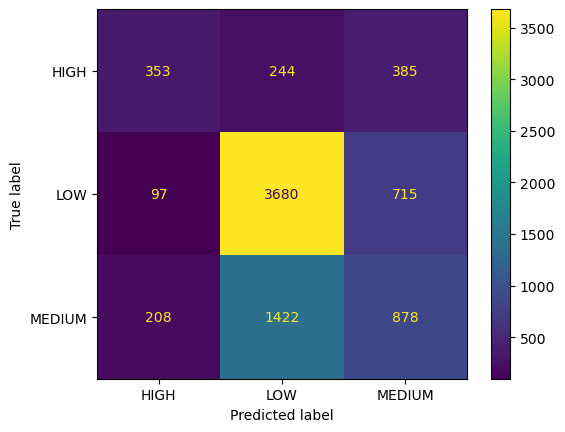

In [960]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

<Axes: ylabel='Feature'>

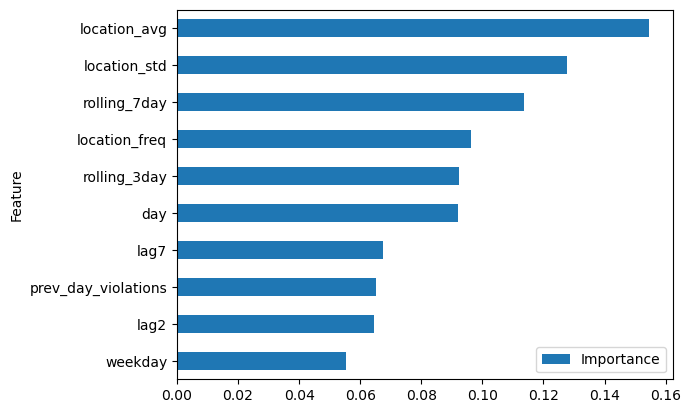

In [961]:
importance.sort_values(
    "Importance"
).tail(10).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

In [962]:
peak_df = df[
    df["hour_ist"].between(8,12)
]

peak_counts = (
    peak_df.groupby("location")
           .size()
)

location_metrics["peak_hour_count"] = (
    peak_counts
)

location_metrics = (
    location_metrics.fillna(0)
)

In [963]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

location_metrics[
    [
        "freq_norm",
        "recurrence_norm",
        "severity_norm",
        "peak_norm"
    ]
] = scaler.fit_transform(
    location_metrics[
        [
            "total_violations",
            "active_days",
            "severity_score",
            "peak_hour_count"
        ]
    ]
)

In [964]:
location_metrics["PCRI"] = (
    0.30 * location_metrics["freq_norm"]
    + 0.20 * location_metrics["recurrence_norm"]
    + 0.25 * location_metrics["severity_norm"]
    + 0.15 * location_metrics["peak_norm"]
    + 0.10 * location_metrics["trend_norm"]
) * 100

In [967]:
#LOW    : PCRI < 50th percentile
# MEDIUM : 50th–85th percentile
# HIGH   : >85th percentile

q50_pcri = (
    location_metrics["PCRI"]
    .quantile(0.50)
)

q85_pcri = (
    location_metrics["PCRI"]
    .quantile(0.85)
)

print("50th percentile =", q50)
print("85th percentile =", q85)

def classify_risk(score):

    if score >= q85_pcri:
        return "HIGH"

    elif score >= q50_pcri:
        return "MEDIUM"

    else:
        return "LOW"

50th percentile = 2.0
85th percentile = 9.0


In [969]:
location_metrics["risk_level"] = (
    location_metrics["PCRI"]
    .apply(classify_risk)
)

<Axes: ylabel='count'>

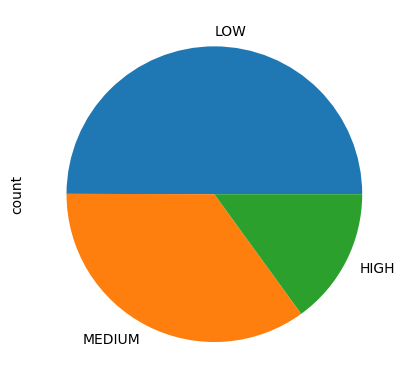

In [970]:
location_metrics["risk_level"].value_counts().plot(kind="pie")

In [971]:
print(
    location_metrics["risk_level"]
    .value_counts()
)

risk_level
LOW       5467
MEDIUM    3833
HIGH      1642
Name: count, dtype: int64


In [972]:
location_metrics["enforcement_priority"] = (
    0.7 * location_metrics["PCRI"]
    + 0.3 * location_metrics["peak_norm"] * 100
)

In [973]:
priority_zones = (
    location_metrics
    .sort_values(
        "enforcement_priority",
        ascending=False
    )
)

priority_zones.head(20)

,total_violations,severity_score,active_days,avg_daily_violations,trend_norm,peak_hour_count,freq_norm,recurrence_norm,severity_norm,peak_norm,PCRI,risk_level,enforcement_priority
location,,,,,,,,,,,,,
"Kamaraj Road, Sri Nagamma Devi Circle, Sivanchetti Gardens, Bengaluru, Karnataka. Pin-560042 (India)",3999,3.313828,149,26.563380,0.576179,2656.0,0.977745,1.000000,0.019614,1.000000,70.584501,HIGH,79.409151
"Dispensary Road, Tasker Town, Shivaji Nagar, Bengaluru, Karnataka. Pin-560001 (India)",2670,3.243820,144,18.445255,0.393203,1983.0,0.652727,0.966216,0.015239,0.746611,54.418296,HIGH,60.491151
"Unnamed Road, Begur Chikkanahalli, Bengaluru, Karnataka. Pin-562149 (India)",4090,4.030807,144,29.072993,0.632744,1297.0,1.000000,0.966216,0.064425,0.488328,64.587321,HIGH,59.860974
"Main Guard Cross Road, Tasker Town, Shivaji Nagar, Bengaluru, Karnataka. Pin-560001 (India)",2549,3.140447,139,17.818182,0.379069,1720.0,0.623135,0.932432,0.008778,0.647590,51.066699,HIGH,55.174400
"New Horizon College Road, New Horizon College of Engineering, Kadubisanahalli, Bengaluru, Karnataka. Pin-560103 (India)",3785,4.794188,86,45.367089,1.000000,1216.0,0.925410,0.574324,0.112137,0.457831,58.919664,HIGH,54.978704
"5th Main Road, Kempe Gowda Circle, Gandhi Nagar, Bengaluru, Karnataka. Pin-560009 (India)",2604,3.062212,144,17.868613,0.380206,1546.0,0.636586,0.966216,0.003888,0.582078,51.052340,HIGH,53.198987
"80 Feet Ring Road, Orion, Brigade Gateway, Malleshwaram West, Bengaluru, Karnataka. Pin-560055 (India)",2117,3.084081,138,15.145038,0.318818,1661.0,0.517486,0.925676,0.005255,0.625377,46.738299,HIGH,51.478104
"Dickenson Road, Sri Nagamma Devi Circle, Sivanchetti Gardens, Bengaluru, Karnataka. Pin-560042 (India)",1924,3.488565,117,15.763636,0.332761,1570.0,0.470286,0.783784,0.030535,0.591114,42.741970,HIGH,47.652813
"MBT Road, Devasandra Junction, KR Puram, Bengaluru, Karnataka. Pin-560036 (India)",3027,4.296663,149,20.492958,0.439356,820.0,0.740034,1.000000,0.081041,0.308735,53.251650,HIGH,46.538203


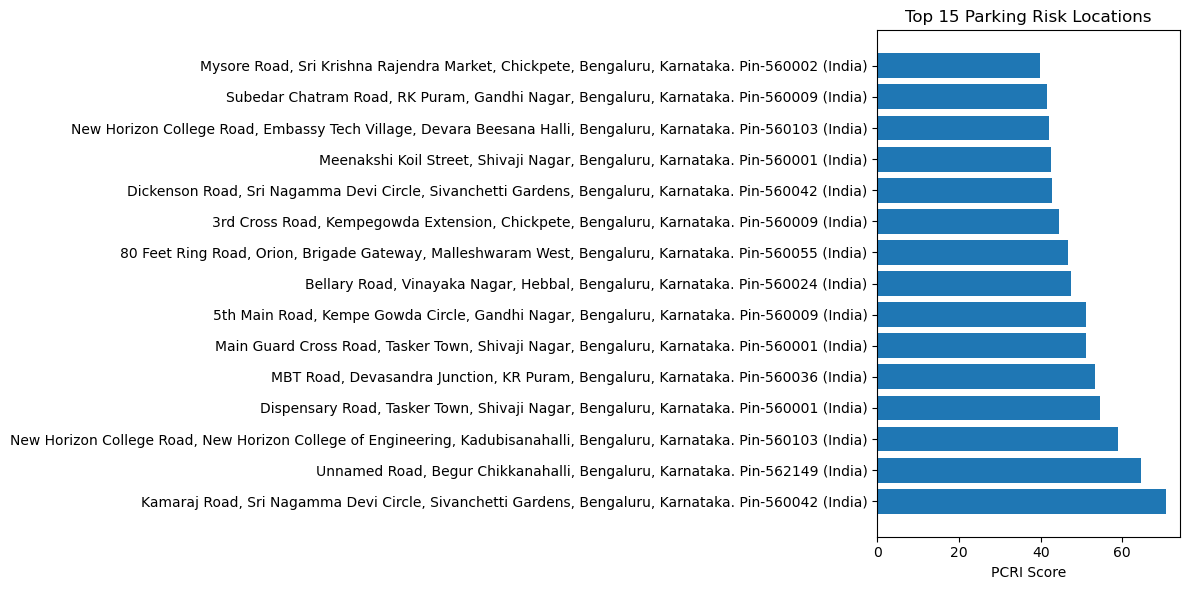

In [974]:
import matplotlib.pyplot as plt

top15 = (
    location_metrics
    .sort_values(
        "PCRI",
        ascending=False
    )
    .head(15)
)

plt.figure(figsize=(12,6))

plt.barh(
    top15.index,
    top15["PCRI"]
)

plt.title(
    "Top 15 Parking Risk Locations"
)

plt.xlabel("PCRI Score")

plt.tight_layout()

plt.show()

In [975]:
heatmap_data = (
    df.groupby(
        ["latitude","longitude"]
    )
    .size()
    .reset_index(
        name="violations"
    )
)

heatmap_data.head()

,latitude,longitude,violations
0,12.802667,77.704312,1
1,12.805449,77.699679,1
2,12.805476,77.699689,1
3,12.805500,77.699668,1
4,12.805583,77.699635,1


In [976]:
heatmap_data.to_csv(
    "heatmap_data.csv",
    index=False
)

In [977]:
print(location_metrics["PCRI"].describe())

count    10942.000000
mean         2.385764
std          4.291207
min          0.000000
25%          0.005648
50%          0.322208
75%          3.248469
max         70.584501
Name: PCRI, dtype: float64


In [978]:
def recommendation(row):

    if row["PCRI"] > q85:
        return "Deploy towing squad and install no-parking cameras"

    elif row["PCRI"] > q50:
        return "Increase patrol frequency during peak hours"

    else:
        return "Regular monitoring"



In [979]:
location_metrics["recommendation"] = (
    location_metrics.apply(
        recommendation,
        axis=1
    )
)